In [513]:
import pandas as pd 
import numpy as np 
import scipy as scp 
import matplotlib.pyplot as plt 
import seaborn as sns
import geopandas as gpd
from pathlib import Path
import matplotlib as mpl

In [131]:
# https://pandas.pydata.org/docs/reference/api/pandas.to_timedelta.html

In [132]:
pasta_de_trabalho = pd.ExcelFile("dados.xlsx").sheet_names
pasta_de_trabalho

['HS',
 'BD',
 'CADASTRO MOTORISTA',
 'SETORES POR DIA',
 'MOVIMENTO',
 'Resumo Diário',
 'ACESSO',
 'Ton-VG-Dia',
 'Planilha1',
 'Dados_gráficos ',
 'Tempo',
 'Tempo_média',
 'KM',
 'KM_média',
 'Ton',
 'Ton_média',
 'Ton_hora_média',
 'ton_KM_média']

In [133]:
df = pd.read_excel("dados.xlsx", sheet_name = "Dados_gráficos ")
df

,Data,Mês,Dia_mês,Dia_semana,Setor,Turno,Carro,Tempo_Coleta,Horas_coleta,Tempo_Trajeto,Tempo_Aterro,KM _COLETA,KM_TRAJETO,PRODUÇÃO,Produção_ton,Viagens,Ton/Horas,Ton/KM
0,2025-04-01,abr,1,ter,10,DIURNO,33048,07:25:00,7.416667,00:38:00,00:32:00,37,27,19890,19.89,2,2.681798,0.537568
1,2025-04-01,abr,1,ter,12,DIURNO,32049,07:41:00,7.683333,02:15:00,00:33:00,37,73,22370,22.37,3,2.911497,0.604595
2,2025-04-01,abr,1,ter,15,DIURNO,32051,08:10:00,8.166667,01:45:00,00:35:00,42,31,23810,23.81,3,2.915510,0.566905
3,2025-04-01,abr,1,ter,17,DIURNO,33049,10:40:00,10.666667,00:50:00,00:45:00,59,17,26220,26.22,3,2.458125,0.444407
4,2025-04-01,abr,1,ter,19,DIURNO,33024,07:06:00,7.100000,01:03:00,00:20:00,47,36,16010,16.01,2,2.254930,0.340638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2826,2026-01-08,jan,8,qui,1,NOTURNO,32050,06:21:00,6.350000,00:41:00,00:25:00,34,31,13600,13.60,2,2.141732,0.400000
2827,2026-01-08,jan,8,qui,2,NOTURNO,32049,06:43:00,6.716667,00:30:00,00:41:00,42,34,10250,10.25,2,1.526055,0.244048
2828,2026-01-08,jan,8,qui,6,NOTURNO,33049,06:06:00,6.100000,00:53:00,00:15:00,41,19,11080,11.08,1,1.816393,0.270244
2829,2026-01-08,jan,8,qui,11,NOTURNO,32101,05:30:00,5.500000,00:24:00,00:26:00,38,22,12040,12.04,2,2.189091,0.316842


In [134]:
df.dtypes

Data             datetime64[ns]
Mês                      object
Dia_mês                   int64
Dia_semana               object
Setor                     int64
Turno                    object
Carro                     int64
Tempo_Coleta             object
Horas_coleta            float64
Tempo_Trajeto            object
Tempo_Aterro             object
KM _COLETA                int64
KM_TRAJETO                int64
PRODUÇÃO                  int64
Produção_ton            float64
Viagens                   int64
Ton/Horas               float64
Ton/KM                  float64
dtype: object

In [228]:
dias_p = df[(df["Dia_semana"] == "seg") | (df["Dia_semana"]== "ter")].copy()
colunas = ["Tempo_Coleta", "Tempo_Aterro", "Tempo_Trajeto"]
for i in colunas:
    dias_p[i] = pd.to_datetime(dias_p[i].astype(str), format = "%H:%M:%S", errors = "coerce")
    dias_p[i] = (dias_p[i] - dias_p[i].dt.normalize())
dias_p["Tempo_Coleta"].dtype

dtype('<m8[ns]')

In [444]:
filtro = dias_p.groupby(["Data","Dia_semana","Turno","Setor", "Mês "]).agg(tempo_coleta = ("Tempo_Coleta", "sum"),
                                                              tempo_trajeto = ("Tempo_Trajeto", "sum"),
                                                              tempo_aterro = ("Tempo_Aterro", "sum"),
                                                              horas_coleta = ("Horas_coleta", "sum"),
                                                              km_coleta = ("KM _COLETA", "sum"),
                                                              km_trajeto = ("KM_TRAJETO", "sum"),
                                                              n_viagens = ("Viagens ", "sum"),
                                                              toneladas = ("Produção_ton", "sum")
                                                              )

filtro.reset_index(drop = False, inplace = True)

filtro1 = filtro[(filtro["Setor"] != 22) & (filtro["Setor"] != 23)].copy()
filtro1["dist_trajeto"] = filtro1["km_trajeto"] / filtro1["n_viagens"]
filtro1["horas_totais"] = filtro1["tempo_aterro"] + filtro1["tempo_coleta"] + filtro1["tempo_trajeto"]
filtro1["horas_totais"] = filtro1["horas_totais"].dt.total_seconds()/3600
filtro1["horas_toneladas"] = filtro1["horas_coleta"]/ filtro1["toneladas"]
filtro1["min_toneladas"] = round(filtro1["horas_toneladas"]*60,0)
filtro1["horas_extras"] = round(filtro1["horas_totais"] - 8.333, 2)
indice = filtro1[filtro1["horas_extras"] <0].index
filtro1.loc[indice,"horas_extras"] =0

filtro1

,Data,Dia_semana,Turno,Setor,Mês,tempo_coleta,tempo_trajeto,tempo_aterro,horas_coleta,km_coleta,km_trajeto,n_viagens,toneladas,dist_trajeto,horas_totais,horas_toneladas,min_toneladas,horas_extras
0,2025-04-01,ter,DIURNO,8,abr,0 days 06:23:00,0 days 00:47:00,0 days 00:25:00,6.383333,28,57,2,13.69,28.500000,7.583333,0.466277,28.0,0.00
1,2025-04-01,ter,DIURNO,10,abr,0 days 07:25:00,0 days 00:38:00,0 days 00:32:00,7.416667,37,27,2,19.89,13.500000,8.583333,0.372884,22.0,0.25
2,2025-04-01,ter,DIURNO,12,abr,0 days 07:41:00,0 days 02:15:00,0 days 00:33:00,7.683333,37,73,3,22.37,24.333333,10.483333,0.343466,21.0,2.15
3,2025-04-01,ter,DIURNO,15,abr,0 days 08:10:00,0 days 01:45:00,0 days 00:35:00,8.166667,42,31,3,23.81,10.333333,10.500000,0.342993,21.0,2.17
4,2025-04-01,ter,DIURNO,17,abr,0 days 10:40:00,0 days 00:50:00,0 days 00:45:00,10.666667,59,17,3,26.22,5.666667,12.250000,0.406814,24.0,3.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
920,2026-01-06,ter,NOTURNO,1,jan,0 days 07:35:00,0 days 01:08:00,0 days 00:37:00,7.583333,34,56,3,18.87,18.666667,9.333333,0.401872,24.0,1.00
921,2026-01-06,ter,NOTURNO,2,jan,0 days 08:16:00,0 days 00:59:00,0 days 00:24:00,8.266667,42,38,2,16.25,19.000000,9.650000,0.508718,31.0,1.32
922,2026-01-06,ter,NOTURNO,6,jan,0 days 07:33:00,0 days 00:46:00,0 days 00:27:00,7.550000,39,43,2,18.36,21.500000,8.766667,0.411220,25.0,0.43
923,2026-01-06,ter,NOTURNO,11,jan,0 days 07:15:00,0 days 00:55:00,0 days 00:25:00,7.250000,38,24,2,20.42,12.000000,8.583333,0.355044,21.0,0.25


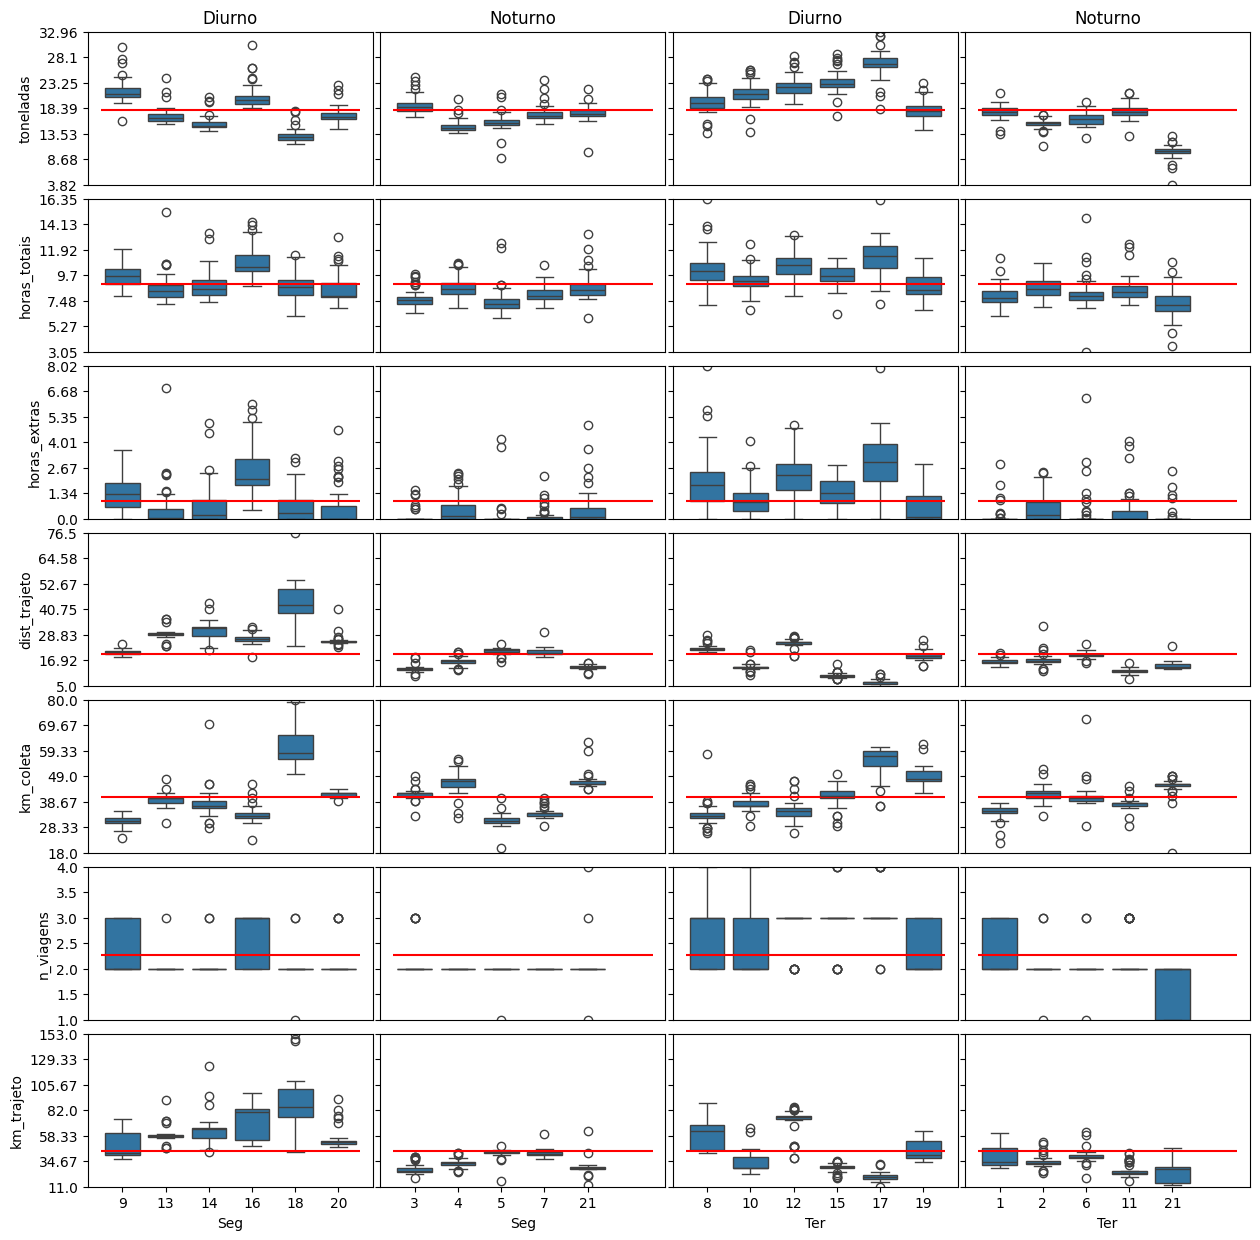

In [459]:
# visualização breve dos principais fatores analisados na coleta de resíduo sólido

seg_d = filtro1[(filtro1["Dia_semana"] == "seg") & (filtro1["Turno"] == "DIURNO")].index
seg_n = filtro1[(filtro1["Dia_semana"] == "seg") & (filtro1["Turno"] == "NOTURNO")].index
ter_d = filtro1[(filtro1["Dia_semana"] == "ter") & (filtro1["Turno"] == "DIURNO")].index
ter_n = filtro1[(filtro1["Dia_semana"] == "ter") & (filtro1["Turno"] == "NOTURNO")].index


turno = ["Diurno", "Noturno", "Diurno", "Noturno"]
dia = ["Seg", "Seg", "Ter", "Ter"]
lista_dados = [seg_d, seg_n, ter_d, ter_n]
lista_var = ["toneladas", "horas_totais","horas_extras", "dist_trajeto","km_coleta", "n_viagens", "km_trajeto"]

figura, axis = plt.subplots(len(lista_var),len(lista_dados), figsize = (15,15))
figura.subplots_adjust(wspace = 0.025, hspace = 0.09)

for i in range(0,len(lista_var)):
    yticks = np.linspace(filtro1[lista_var[i]].min(), filtro1[lista_var[i]].max(), 7)

    for j in range(0,len(lista_dados)):
        sns.boxplot(ax = axis[i,j], data = filtro1.loc[lista_dados[j]], x = "Setor", y = lista_var[i], legend= "full")
        axis[i,j].hlines(xmin = -0.5, xmax = 5.5, y = filtro1[lista_var[i]].mean(), color = "red")
        axis[i,j].set_yticks(ticks = yticks, labels = yticks.round(2))
        axis[i,j].set(ylim = [filtro1[lista_var[i]].min(),  filtro1[lista_var[i]].max()])
         
         

        if j != 0:
            axis[i,j].set_yticks(ticks = yticks, labels = [])
            axis[i,j].set(ylabel = "")
            
        if i==0:
            axis[i,j].set( title = turno[j])
      
        
        if i != len(lista_var) -1:
            axis[i,j].set(xlabel = "", xticks = [])
        else: 
            axis[i,j].set(xlabel = dia[j] )
            




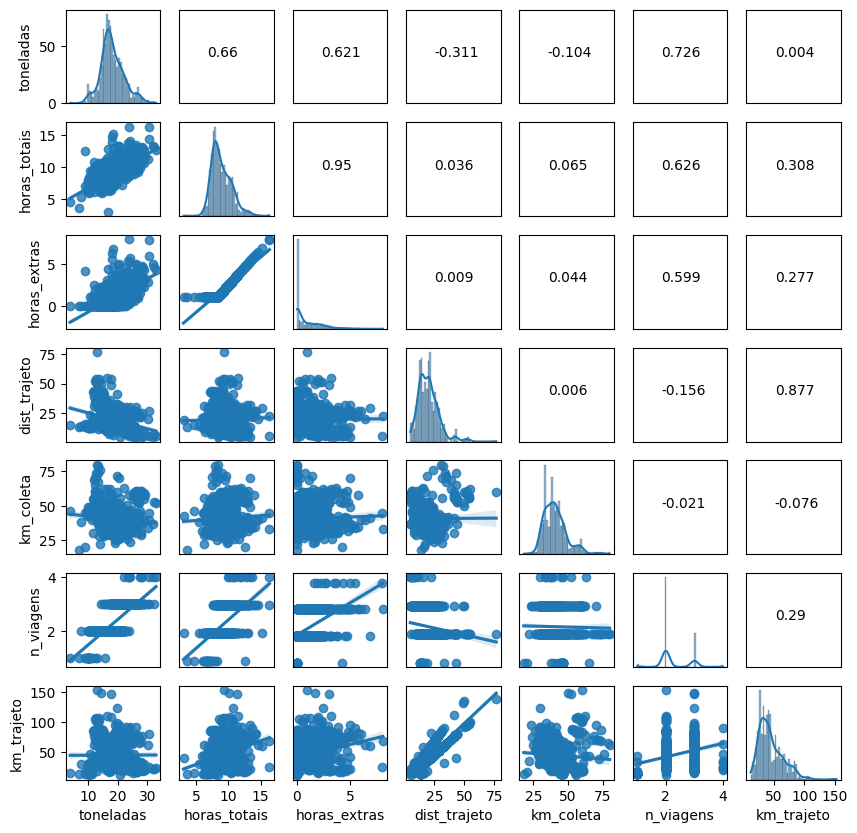

In [ ]:
# verificação da correlação entre as variáveis 
# nota-se que a tonelagem dos setores e a quantidade de viagens tem grande interferência na quantidade de horas extras
# o intuito da readequação é remapear a cidade, deixando cada setor com uma quantidade igual de toneladas

import pli_uso_pro as pup

pup.matriz_corr(filtro1, lista_var, (10,10))

In [462]:
# média de horas extras mensais e de kilômetros percorridos por trajeto, que são os maiores disperdícios da operação 

disp = filtro1.groupby("Mês ").agg(horas_extras = ("horas_extras", "sum"), km_trajeto = ("km_trajeto", "sum"))
disp.reset_index(inplace = True)
disp


,Mês,horas_extras,km_trajeto
0,abr,102.31,4163
1,ago,51.98,3857
2,dez,261.12,5323
3,jan,40.79,1263
4,jul,71.48,4458
5,jun,53.02,4212
6,mai,61.62,3670
7,nov,59.37,3826
8,out,51.73,3754
9,set,70.32,4939


[[], []]

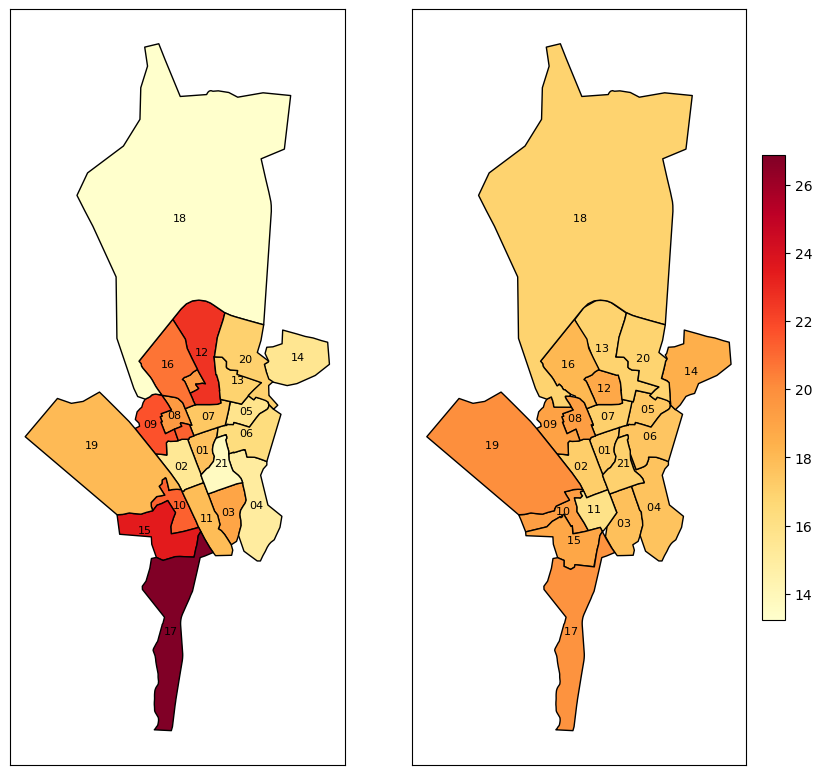

In [543]:
caminho = Path("C:\\Users\\felip\\OneDrive\\Documentos\\Projeto_mestrado\\Analise descritiva\\Sustentare_readequação\\arquivos georeferenciados\\Setores_atuais")
caminho1 = Path("C:\\Users\\felip\\OneDrive\\Documentos\\Projeto_mestrado\\Analise descritiva\\Sustentare_readequação\\arquivos georeferenciados\\Setores_readequação")

arquivo_shp = caminho / "01.shp"
arquivo_shp1 = caminho1 / "01C.shp"

mapas = gpd.read_file(arquivo_shp)
mapas1 = gpd.read_file(arquivo_shp1)

for i in range(2,22):
  if i <10:
    arquivo_shp = caminho / f"0{i}.shp"
    arquivo_shp1 = caminho1 / f"0{i}C.shp"
    tent = gpd.read_file(arquivo_shp)
    tent1 = gpd.read_file(arquivo_shp1)
    mapas = pd.concat([mapas,tent])
    mapas1 = pd.concat([mapas1,tent1])
  else:
    arquivo_shp = caminho / f"{i}.shp"
    arquivo_shp1 = caminho1 / f"{i}C.shp"
    tent = gpd.read_file(arquivo_shp)
    tent1 = gpd.read_file(arquivo_shp1)
    mapas = pd.concat([mapas,tent])
    mapas1 = pd.concat([mapas1,tent1])



mapas["turno"] = mapas["FREQUENCIA"].str.extract(r"(DIURNO|NOTURNO)")
mapas["frequencia"] = mapas["FREQUENCIA"].str.extract(r"(TER/QUI/SAB|SEG/QUA/SEX|SEG, TER, QUA, QUI, SEX, SAB)")
mapas = mapas.drop("FREQUENCIA", axis = 1)
mapas["label_point"] = mapas.geometry.representative_point()
tonelagem = filtro1.groupby("Setor")["toneladas"].mean()
mapas["ton"] = tonelagem.values

tonelagem1 = pd.read_excel("Proposta_setores_1.xlsx", sheet_name = "ton_prev")
mapas1["turno"] = mapas1["FREQUENCIA"].str.extract(r"(DIURNO|NOTURNO)")
mapas1["frequencia"] = mapas1["FREQUENCIA"].str.extract(r"(TER/QUI/SAB|SEG/QUA/SEX|SEG, TER, QUA, QUI, SEX, SAB)")
mapas1 = mapas1.drop("FREQUENCIA", axis = 1)
mapas1["label_point"] = mapas1.geometry.representative_point()
mapas1["ton"] = tonelagem1["ton"].values

avmax = tonelagem.max()
avmin = tonelagem.min()

figura, axis = plt.subplots(1,2,figsize = (10,15))
mapas.plot(edgecolor = "black", figsize = (20,20), column = "ton", ax = axis[0], cmap = "YlOrRd", vmin = avmin, vmax = avmax)
mapas1.plot(edgecolor = "black", figsize = (20,20), column = "ton", ax = axis[1], cmap = "YlOrRd", vmin = avmin, vmax = avmax)


norm = mpl.colors.Normalize(vmin=avmin, vmax=avmax)
sm = plt.cm.ScalarMappable(norm=norm, cmap="YlOrRd")
cbar = figura.colorbar(sm, ax=axis, fraction=0.03, pad=0.02)

for idx, row in mapas.iterrows():
  x = row["label_point"].x
  y = row["label_point"].y
  axis[0].text(x, y,row["SETOR"],ha="center",va="center",fontsize=8,color="black")

apagar = r"(CLONE C)|(CLONE B)|(CLONE a)"
mapas1["APELIDO"] = mapas1["APELIDO"].str.replace(apagar, "", regex = True)
for idx, row in mapas1.iterrows():
  x = row["label_point"].x
  y = row["label_point"].y
  axis[1].text(x, y,row["APELIDO"],ha="center",va="center",fontsize=8,color="black")

axis[0].set(xticks = [], yticks = [])
axis[1].set(xticks = [], yticks = [])

